In [122]:
from src import data_processing as dp
from src import cost_calculations as cc
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
CONFIG = dp.ElectricityConfig.from_yaml("../config/config.yaml")

# df_hourly = dp.process_hourly_energy_profile(start_date="2024-12-01 00:00", end_date="2025-11-30 23:45")
df_hourly = dp.process_heat_energy_profile()
day_ahead_hourly = dp.process_day_ahead_data(df_hourly)

df_usage_and_price = dp.calculate_usage_and_price(df_hourly, day_ahead_hourly, config=CONFIG)
hourly_daily_avg = dp.shift_electricity_usage_daily(df_usage_and_price, config=CONFIG)

merged_df = dp.merge_temperature_shift_with_usage(df_usage_and_price, hourly_daily_avg,config=CONFIG)

merged_df = merged_df[merged_df.datetime < '2025-12-01']

allocated_storage = dp.allocate_battery_storage(merged_df, config=CONFIG)
# allocated_storage = dp.chatgpt_allocate_battery_storage(merged_df, config=CONFIG)

print(f'Variable cost with battery: €{allocated_storage["c_variable_total_cost_with_battery"].sum()/100:,.2f}')
print(f'Variable cost without battery: €{allocated_storage["c_total_variable_cost"].sum()/100:,.2f}')
print(f'Flat costs: €{allocated_storage["c_total_flat_cost"].sum()/100:,.2f}')
print(f'Total Usage: {allocated_storage["raw_kwh_usage"].sum():,.2f}kWh')
print(f'Scaled Usage: {allocated_storage["scaled_kwh_usage"].sum():,.2f}kWh')
print(f'Variable Cost per kWh without battery: {allocated_storage["c_total_variable_cost"].sum()/allocated_storage["scaled_kwh_usage"].sum():,.2f}c/kWh')
print(f'Variable Cost per kWh with battery: {allocated_storage["c_variable_total_cost_with_battery"].sum()/allocated_storage["scaled_kwh_usage"].sum():,.2f}c/kWh')
print(f'Flat Cost per kWh without battery: {allocated_storage["c_total_flat_cost"].sum()/allocated_storage["scaled_kwh_usage"].sum():,.2f}c/kWh')
# shifted_usage = dp.calculate_shifted_electricity_cost(df_usage_and_price, hourly_monthly_avg, config=CONFIG)

/Users/neil.sinclair@diconium.com/Projects/electricy-model/src/data_processing.py:139: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  day_ahead = pd.read_csv("data/day_ahead_1yr.csv", sep=";")


c_flat_cost_per_kwh: 0.03
Variable cost with battery: €30,082.38
Variable cost without battery: €31,388.80
Flat costs: €37,953.15
Total Usage: 106,311.34kWh
Scaled Usage: 106,311.34kWh
Variable Cost per kWh without battery: 29.53c/kWh
Variable Cost per kWh with battery: 28.30c/kWh
Flat Cost per kWh without battery: 35.70c/kWh


In [131]:
merged_df.head()

save_df = merged_df[["raw_kwh_usage", "c_variable_and_fixed_per_kwh"]]
save_df.to_csv("data/usage_and_price.csv", index=False)

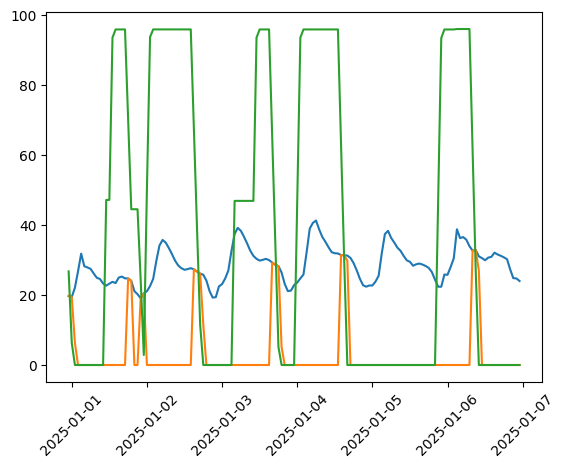

In [124]:
import matplotlib.pyplot as plt
# plt.plot(allocated_storage['datetime'], allocated_storage['scaled_kwh_usage'])
temp_df = allocated_storage[allocated_storage['datetime'] < '2025-01-07']
plt.plot(temp_df['datetime'], temp_df['scaled_kwh_usage'])
plt.plot(temp_df['datetime'], temp_df['battery_discharge'], label='Battery Discharge')
plt.plot(temp_df['datetime'], temp_df['battery_level'], label='Battery Discharge')
plt.xticks(rotation=45);

In [127]:
import pandas as pd
pd.set_option('display.max_rows', 240)
allocated_storage[(allocated_storage["datetime"] < '2025-01-07') & (allocated_storage["datetime"] >= '2025-01-05')][[
    "datetime", "raw_kwh_usage", "c_variable_and_fixed_per_kwh", "stored_per_hour_kwh", "battery_level", "battery_discharge", "usage_with_battery"
    ]].head(240)

,datetime,raw_kwh_usage,c_variable_and_fixed_per_kwh,stored_per_hour_kwh,battery_level,battery_discharge,usage_with_battery
97,2025-01-05 00:00:00,22.719466,26.134,0.000000,0.000000,0.000000,22.719466
98,2025-01-05 01:00:00,23.834532,24.783,0.000000,0.000000,0.000000,23.834532
99,2025-01-05 02:00:00,25.507131,24.111,0.000000,0.000000,0.000000,25.507131
100,2025-01-05 03:00:00,31.918760,24.137,0.000000,0.000000,0.000000,31.918760
101,2025-01-05 04:00:00,37.424397,23.688,0.000000,0.000000,0.000000,37.424397
102,2025-01-05 05:00:00,38.330388,23.105,0.000000,0.000000,0.000000,38.330388
103,2025-01-05 06:00:00,36.309331,23.142,0.000000,0.000000,0.000000,36.309331
104,2025-01-05 07:00:00,34.985191,23.003,0.000000,0.000000,0.000000,34.985191
105,2025-01-05 08:00:00,33.521667,23.155,0.000000,0.000000,0.000000,33.521667
106,2025-01-05 09:00:00,32.615676,23.665,0.000000,0.000000,0.000000,32.615676


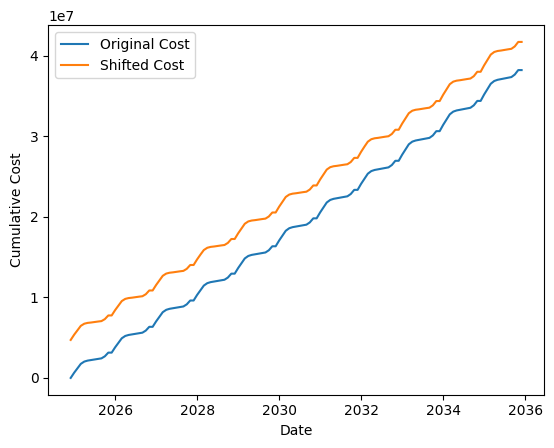

In [39]:
import matplotlib.pyplot as plt
projections = cc.calculate_projections(allocated_storage, config=CONFIG)
battery_capex = (CONFIG.BATTERY_SIZE_KWH * CONFIG.BATTERY_COST_PER_KWH * (1 + CONFIG.TAX_RATE)) * 100

projections.loc[:, "c_variable_total_cost_with_battery_cumulative"] = projections.loc[:, "c_variable_total_cost_with_battery_cumulative"] + battery_capex + (battery_capex * CONFIG.OPEX_PERCENT_OF_CAPEX)

plt.plot(projections["datetime"], projections["c_total_variable_cost_cumulative"], label="Original Cost")
plt.plot(projections["datetime"], projections["c_variable_total_cost_with_battery_cumulative"], label="Shifted Cost")
plt.xlabel("Date")
plt.ylabel("Cumulative Cost")
plt.legend()
plt.show()

In [9]:
CONFIG.BATTERY_SIZE_KWH * CONFIG.BATTERY_COST_PER_KWH

30000

In [ ]:
print(f'Shifted usage cost: €{shifted_usage["c_total_variable_shifted_cost"].sum():,.2f}')
print(f'Original usage cost: €{shifted_usage["c_total_variable_cost"].sum():,.2f}')

print(f'Shifted usage amount: {shifted_usage["shifted_usage_kwh"].sum():,.2f} kWh')
print(f'Original usage amount: {shifted_usage["scaled_kwh_usage"].sum():,.2f} kWh')

Shifted usage cost: €1,261,485.89
Original usage cost: €1,431,919.31
Shifted usage amount: 50,055.19 kWh
Original usage amount: 50,055.19 kWh


In [5]:
import pandas as pd
import numpy as np

def allocate_battery_storage(df: pd.DataFrame, config: dp.ElectricityConfig) -> pd.DataFrame:
    """Function which allocates battery storage
    
    Alogrithm: for each day, sort hours by cost ascending, then allocate charge to the battery until the battery's
    full given the constrain that we can only put in config.BATTERY_POWER kWh per hour. We cannot overfill the battery
    and we need to keep a running total of the battery level across days.

    Args:
        df (pd.DataFrame): DataFrame with hourly electricity data
        config (dp.ElectricityConfig): Configuration object with battery parameters
    
    Returns:
        pd.DataFrame: DataFrame with additional columns for battery storage allocation
    
    """

    battery_max = config.BATTERY_SIZE_KWH * config.SOC_FACTOR

    df = df.copy()
    # df["day_of_year"] = df["datetime"].dt.day_of_year
    # df["year"] = df["datetime"].dt.year

    df["battery_level"] = 0
    battery_storage = 0

    for (year, day), df_temp in df.groupby(["year", "day_of_year"]):
        df_temp = df_temp.sort_values("c_per_kwh_variable")
        
        for idx, row in df_temp.iterrows():
            if battery_storage >= battery_max:
                df.loc[(df["year"] == year) & (df["day_of_year"] == day), "battery_level"] = battery_storage
                break

            charge_amount = min(config.BATTERY_POWER,
                                battery_max - battery_storage)

            df.at[idx, "stored_per_hour_kwh"] = charge_amount
            battery_storage += charge_amount
            df.at[idx, "battery_level"] = battery_storage

    print(charge_amount)
    return df

x = allocate_battery_storage(shifted_usage, CONFIG)
x

NameError: name 'shifted_usage' is not defined

In [59]:
charge_amount

NameError: name 'charge_amount' is not defined

In [68]:
import pandas as pd
import numpy as np
pd.set_option('display.max_rows', 48)
def allocate_battery_storage(df: pd.DataFrame, config: dp.ElectricityConfig) -> pd.DataFrame:
    """Function which allocates battery storage
    
    Alogrithm: for each day, sort hours by cost ascending, then allocate charge to the battery until the battery's
    full given the constrain that we can only put in config.BATTERY_POWER kWh per hour. We cannot overfill the battery
    and we need to keep a running total of the battery level across days.

    Args:
        df (pd.DataFrame): DataFrame with hourly electricity data
        config (dp.ElectricityConfig): Configuration object with battery parameters
    
    Returns:
        pd.DataFrame: DataFrame with additional columns for battery storage allocation
    
    """

    battery_max = config.BATTERY_SIZE_KWH * config.SOC_FACTOR

    df = df.copy()
    # df["day_of_year"] = df["datetime"].dt.day_of_year
    # df["year"] = df["datetime"].dt.year

    df["stored_per_hour_kwh"] = 0.0
    df["battery_discharge"] = 0.0
    df["battery_level"] = 0.0
    df["reverse_temperature_weighted_usage"] = 1.0 - df["temperature_weighted_usage"]
    df["reverse_scaled_usage"] = 0.0
    battery_storage = 0.0

    for year in df["year"].unique():
        for day in df.loc[df["year"] == year, "day_of_year"].unique():  # type: ignore
            mask = (df["day_of_year"] == day) & (df["year"] == year)
            df_temp = df.loc[mask].sort_values(by="c_per_kwh_variable")
            for idx, row in df_temp.iterrows():
                if battery_storage < battery_max:
                    charge_amount = min(battery_max - battery_storage, config.BATTERY_POWER)
                    battery_storage += charge_amount
                    df.at[idx, "stored_per_hour_kwh"] = charge_amount
                else:
                    df.at[idx, "stored_per_hour_kwh"] = 0.0
                # df.at[idx, "battery_level"] = battery_storage 

            for idx, row in df.loc[mask].iterrows():
                df.at[idx, "battery_level"] = min(df.at[max(idx-1,0), "battery_level"] + df.at[idx, "stored_per_hour_kwh"], config.BATTERY_SIZE_KWH * config.SOC_FACTOR)  # type: ignore
                
                battery_discharge = (1.0 - df.at[idx, "temperature_weighted_usage"]) * df.at[idx, "scaled_kwh_usage"]  # type: ignore
                
                df.at[idx, "battery_discharge"] = min(df.at[idx, "battery_level"], battery_discharge)  # type: ignore
                battery_storage -= battery_discharge  # type: ignore
                df.at[idx, "battery_level"] = max(df.at[idx, "battery_level"] - df.at[idx, "battery_discharge"],0)  # type: ignore
            
    return df

x = allocate_battery_storage(merged_df, CONFIG)
# x.loc[2400:2424, ["datetime", "c_per_kwh_variable", "scaled_kwh_usage", "temperature_weighted_usage", "shifted_usage_kwh", "stored_per_hour_kwh", "reverse_scaled_usage", "battery_level"] ]
x.loc[4800:4847,["datetime", "c_per_kwh_variable", "scaled_kwh_usage", "temperature_weighted_usage", "stored_per_hour_kwh", "reverse_scaled_usage", "battery_discharge", "battery_level"] ]



,datetime,c_per_kwh_variable,scaled_kwh_usage,temperature_weighted_usage,stored_per_hour_kwh,reverse_scaled_usage,battery_discharge,battery_level
4800,2025-06-19 00:00:00,11.220,2.71365,6.924010e-76,0.000000,0.0,2.713650,47.989715
4801,2025-06-19 01:00:00,10.640,2.6383,1.938614e-73,0.000000,0.0,2.638300,45.351415
4802,2025-06-19 02:00:00,10.529,2.60215,5.699306e-73,0.000000,0.0,2.602150,42.749265
4803,2025-06-19 03:00:00,9.951,2.647,1.565010e-70,0.000000,0.0,2.647000,40.102265
4804,2025-06-19 04:00:00,10.094,2.80455,3.900966e-71,0.000000,0.0,2.804550,37.297715
4805,2025-06-19 05:00:00,9.568,3.2962,6.463521e-69,0.000000,0.0,3.296200,34.001515
4806,2025-06-19 06:00:00,10.151,4.5096,2.242219e-71,0.000000,0.0,4.509600,29.491915
4807,2025-06-19 07:00:00,8.925,6.89615,3.337429e-66,0.000000,0.0,6.896150,22.595765
4808,2025-06-19 08:00:00,7.125,9.314,1.312093e-58,0.000000,0.0,9.314000,13.281765
4809,2025-06-19 09:00:00,0.086,10.4672,6.559697e-29,0.000000,0.0,10.467200,2.814565


In [105]:
import pandas as pd
import numpy as np

def allocate_battery_storage(df: pd.DataFrame, config) -> pd.DataFrame:
    """
    Allocate battery storage chronologically while selecting cheapest hours
    for charging on each day.

    Charging rule:
        - Precompute cheapest hours in the day (sorted by cost)
        - But THEN step through the day chronologically and charge only when
          current hour is one of the selected cheap hours.
        - Apply per-hour max charging rate: config.BATTERY_POWER
        - Keep battery continuity across days (does not reset at midnight)
    """

    df = df.copy()
    df["stored_per_hour_kwh"] = 0.0
    df["battery_discharge"] = 0.0
    df["battery_level"] = 0.0
    df["reverse_temperature_weighted_usage"] = 1.0 - df["temperature_weighted_usage"]

    battery_max = config.BATTERY_SIZE_KWH * config.SOC_FACTOR
    battery_storage = 0.0

    # group by day/year
    for year in df["year"].unique():
        days = df.loc[df["year"] == year, "day_of_year"].unique()

        for day in days:
            mask = (df["year"] == year) & (df["day_of_year"] == day)

            day_df = df.loc[mask]

            # ---- STEP 1: Determine which hours are used for charging (cheapest hours first) ---- #
            # Theoretical hours you *could* charge: as many hours as needed to fill battery
            # at max power per hour
            hours_needed_to_fill = int(np.ceil((battery_max - battery_storage) / config.BATTERY_POWER))
            hours_needed_to_fill = max(hours_needed_to_fill+1, 0)

            cheap_indices = (
                day_df.sort_values("c_per_kwh_variable")
                      .head(hours_needed_to_fill)
                      .index
            )

            # ---- STEP 2: Chronological loop for the actual operations ---- #
            for idx in day_df.sort_values("datetime").index:

                # --- CHARGING --- #
                if idx in cheap_indices and battery_storage < battery_max:
                    charge_amount = min(
                        config.BATTERY_POWER,
                        battery_max - battery_storage
                    )
                    battery_storage += (charge_amount * config.BATTERY_INEFFICIENCY_FACTOR)
                    df.at[idx, "stored_per_hour_kwh"] = charge_amount

                # --- DISCHARGING --- #
                # how much usage we want to offset from battery
                if df.at[idx, "stored_per_hour_kwh"] > 10:
                    discharge_need = 0
                else:
                    discharge_need = df.at[idx, "reverse_temperature_weighted_usage"] * df.at[idx, "scaled_kwh_usage"]
                
                actual_discharge = max(min(battery_storage, discharge_need),0)

                df.at[idx, "battery_discharge"] = actual_discharge 
                battery_storage -= actual_discharge * (1/ config.BATTERY_INEFFICIENCY_FACTOR)

                # --- UPDATE LEVEL --- #
                df.at[idx, "battery_level"] = max(battery_storage, 0)

    return df

x = allocate_battery_storage(merged_df, CONFIG)
# x.loc[2400:2447,["datetime", "c_per_kwh_variable", "scaled_kwh_usage", "temperature_weighted_usage", "stored_per_hour_kwh", "battery_discharge", "battery_level"] ]

x["usage_with_battery"] = x["scaled_kwh_usage"] - x["battery_discharge"] + x["stored_per_hour_kwh"]
x["c_variable_total_cost_with_battery"] = x["usage_with_battery"] * x["c_variable_and_fixed_per_kwh"] * (1 + CONFIG.TAX_RATE)

print(f'Variable cost with battery: €{x["c_variable_total_cost_with_battery"].sum():,.2f}')
print(f'Variable cost without battery: €{x["c_total_variable_cost"].sum():,.2f}')
print(f'Flat costs: €{x["c_total_flat_cost"].sum():,.2f}')


Variable cost with battery: €1,281,715.84
Variable cost without battery: €1,431,919.31
Flat costs: €1,786,970.39


In [104]:
x.loc[2400:2447,["datetime", "c_per_kwh_variable", "scaled_kwh_usage", "temperature_weighted_usage", "stored_per_hour_kwh", "battery_discharge", "battery_level"] ]

,datetime,c_per_kwh_variable,scaled_kwh_usage,temperature_weighted_usage,stored_per_hour_kwh,battery_discharge,battery_level
2400,2025-03-11 00:00:00,10.439,2.8982,1.612238e-04,0.000000,2.897733,22.033001
2401,2025-03-11 01:00:00,10.180,2.8289,2.416562e-03,0.000000,2.822064,19.062407
2402,2025-03-11 02:00:00,9.973,2.80665,2.103318e-02,0.000000,2.747617,16.170179
2403,2025-03-11 03:00:00,10.050,2.8746,9.404855e-03,0.000000,2.847565,13.172742
2404,2025-03-11 04:00:00,10.253,3.09295,1.126688e-03,0.000000,3.089465,9.920673
2405,2025-03-11 05:00:00,11.086,3.8307,1.863275e-07,0.000000,3.830699,5.888358
2406,2025-03-11 06:00:00,14.804,5.53435,2.465282e-24,0.000000,5.534350,0.062727
2407,2025-03-11 07:00:00,15.298,8.5543,1.410200e-26,0.000000,0.062727,0.000000
2408,2025-03-11 08:00:00,14.649,11.31385,1.245983e-23,0.000000,0.000000,0.000000
2409,2025-03-11 09:00:00,12.853,12.4257,1.773044e-15,0.000000,0.000000,0.000000


In [100]:
9.357500e+01

93.575

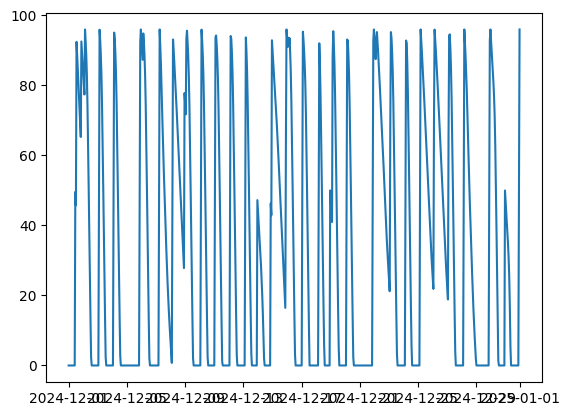

In [71]:
import matplotlib.pyplot as plt
plt.plot(x[x.year==2024]["datetime"], x[x.year==2024]["battery_level"])

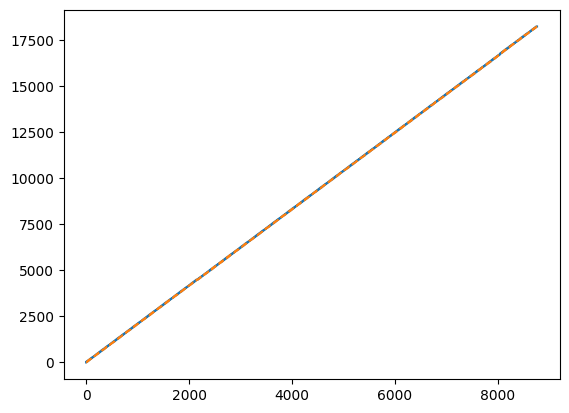

In [30]:
import pandas as pd
import numpy as np
def draw_battery_power(df: pd.DataFrame, config: dp.ElectricityConfig) -> pd.DataFrame:
    """Function which cycles through each row in the table and calculates battery storage levels.
    
    For each hour, we check how much power is stored in the battery and then how much power needs to be discharged.
    We subtract the discharge from the stored power up to maximum of 50kW. 

    Args:
        df (pd.DataFrame): Dataframe containing shifted usage data.
        config (dp.ElectricityConfig): Configuration object containing battery parameters.

    Returns:
        pd.DataFrame: Dataframe
    """
    df = df.copy()
    
    # Calculate power stored per hour
    df["stored_per_hour_kwh"] = df["temperature_weighted_usage"] * config.BATTERY_POWER
    
    # Initialize arrays for battery state
    n = len(df)
    remaining_storage = np.zeros(n)
    discharge_amount = np.zeros(n)
    
    current_storage = 0.0
    
    for i in range(n):
        # Add stored power
        current_storage += min(df.iloc[i]["stored_per_hour_kwh"], config.BATTERY_SIZE_KWH)
        
        # Calculate discharge such that we're only trying to discharge when electricity is not cheap
        discharge_request = df.iloc[i]["scaled_kwh_usage"] * (1 - df.iloc[i]["temperature_weighted_usage"] )
        discharge = min(discharge_request, config.BATTERY_POWER, current_storage)
        
        # Update storage
        current_storage -= discharge
        
        # Store values
        remaining_storage[i] = current_storage
        discharge_amount[i] = discharge
    
    df["battery_discharge_request_kwh"] = discharge_amount
    df["remaining_storage_kwh"] = remaining_storage
    
    return df


import matplotlib.pyplot as plt
battery_storage = draw_battery_power(shifted_usage, CONFIG)
# battery_storage["stored_per_hour_kwh"].hist()
plt.plot(battery_storage["stored_per_hour_kwh"].cumsum())
plt.plot(battery_storage["battery_discharge_request_kwh"].cumsum(), linestyle='--')

In [46]:
battery_storage.columns

Index(['month_name', 'datetime', 'raw_kwh_usage', 'c_per_kwh_variable',
       'month', 'month_name_x', 'scaled_kwh_usage', 'c_fixed_costs_kwh',
       'c_variable_and_fixed_per_kwh', 'c_total_variable_cost',
       'c_per_kwh_flat_rate_cost', 'c_total_flat_cost', 'month_name_y',
       'temperature_weighted_usage', 'shifted_usage_kwh',
       'c_total_variable_shifted_cost', 'stored_per_hour_kwh',
       'battery_discharge_request_kwh', 'remaining_storage_kwh'],
      dtype='object')

In [48]:
pd.set_option('display.max_rows', 40)
battery_storage.loc[2400:2424, ["datetime", "c_per_kwh_variable", "scaled_kwh_usage", "temperature_weighted_usage", "shifted_usage_kwh", "stored_per_hour_kwh", "battery_discharge_request_kwh", "remaining_storage_kwh"]]

,datetime,c_per_kwh_variable,scaled_kwh_usage,temperature_weighted_usage,shifted_usage_kwh,stored_per_hour_kwh,battery_discharge_request_kwh,remaining_storage_kwh
2400,2025-03-11 00:00:00,10.439,2.8982,1.567738e-35,0.0,7.838690e-34,7.838690e-34,0.000000
2401,2025-03-11 01:00:00,10.180,2.8289,3.184485e-32,0.0,1.592243e-30,1.592243e-30,0.000000
2402,2025-03-11 02:00:00,9.973,2.80665,1.242018e-32,0.0,6.210090e-31,6.210090e-31,0.000000
2403,2025-03-11 03:00:00,10.050,2.8746,1.306215e-30,0.0,6.531074e-29,6.531074e-29,0.000000
2404,2025-03-11 04:00:00,10.253,3.09295,2.077468e-31,0.0,1.038734e-29,1.038734e-29,0.000000
2405,2025-03-11 05:00:00,11.086,3.8307,3.821050e-36,0.0,1.910525e-34,1.910525e-34,0.000000
2406,2025-03-11 06:00:00,14.804,5.53435,3.333300e-47,0.0,1.666650e-45,1.666650e-45,0.000000
2407,2025-03-11 07:00:00,15.298,8.5543,1.074551e-51,0.0,5.372756e-50,5.372756e-50,0.000000
2408,2025-03-11 08:00:00,14.649,11.31385,1.976704e-43,0.0,9.883519e-42,9.883519e-42,0.000000
2409,2025-03-11 09:00:00,12.853,12.4257,2.734224e-30,0.0,1.367112e-28,1.367112e-28,0.000000


6.778415e-06

,datetime,c_total_variable_cost,c_total_variable_shifted_cost,c_total_variable_cost_cumulative,c_total_variable_shifted_cost_cumulative
0,2024-12-01,146886.727627,125091.113517,146886.727627,125091.113517
1,2025-01-01,154062.875508,142432.353316,300949.603136,267523.466833
2,2025-02-01,142529.890645,142076.036778,443479.49378,409599.503611
3,2025-03-01,128039.266286,108771.78943,571518.760066,518371.293041
4,2025-04-01,105145.846125,83944.058792,676664.606191,602315.351833
...,...,...,...,...,...
127,2035-07-01,129655.978405,116776.384468,16859628.203829,14840362.916283
128,2035-08-01,121419.07031,101674.065413,16981047.274139,14942036.981695
129,2035-09-01,130399.617371,112787.842371,17111446.89151,15054824.824067
130,2035-10-01,145279.16249,137766.219283,17256726.054,15192591.04335


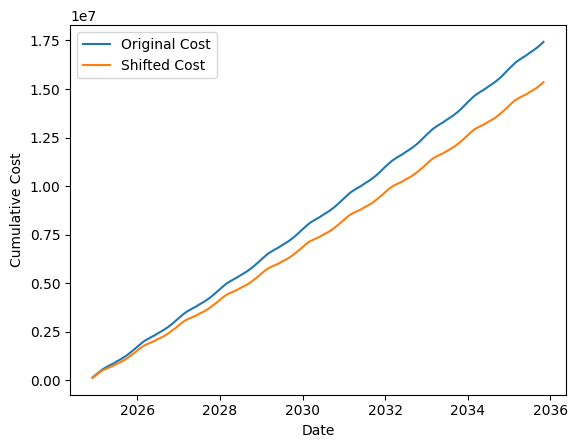

In [9]:
monthly_costs = shifted_usage.resample("MS", on="datetime").agg({
    "c_total_variable_cost": "sum",
    "c_total_variable_shifted_cost": "sum"
}).reset_index()

monthly_costs

,datetime,c_total_variable_cost,c_total_variable_shifted_cost
0,2024-12-01,146886.727627,125091.113517
1,2025-01-01,154062.875508,142432.353316
2,2025-02-01,142529.890645,142076.036778
3,2025-03-01,128039.266286,108771.78943
4,2025-04-01,105145.846125,83944.058792
...,...,...,...
7,2025-07-01,106363.061453,95797.308464
8,2025-08-01,99605.927902,83408.146703
9,2025-09-01,106973.104415,92525.314736
10,2025-10-01,119179.513956,113016.283769


In [ ]:
import pandas as pd
dt_index = pd.date_range(
    start=monthly_costs["datetime"].min(),
    end=monthly_costs["datetime"].max() + pd.Timedelta(weeks=(52*10)+2),   # last 15-minute slot of the year
    freq="MS"
)

df_dates = pd.DataFrame({"datetime": dt_index})

monthly_costs_extended = pd.merge(
    df_dates,
    monthly_costs,
    on="datetime",
    how="left"
)

for d in monthly_costs_extended.datetime:
    if d <= monthly_costs_extended["datetime"].max() - pd.Timedelta(weeks=52):
        next_year = (d + pd.DateOffset(years=1)).to_period('M').to_timestamp()
        
        # Get scalar values instead of Series
        current_variable_cost = monthly_costs_extended.loc[monthly_costs_extended["datetime"] == d, "c_total_variable_cost"].values[0]
        current_shifted_cost = monthly_costs_extended.loc[monthly_costs_extended["datetime"] == d, "c_total_variable_shifted_cost"].values[0]
        
        monthly_costs_extended.loc[monthly_costs_extended["datetime"] == next_year, "c_total_variable_cost"] = current_variable_cost * 1.02
        monthly_costs_extended.loc[monthly_costs_extended["datetime"] == next_year, "c_total_variable_shifted_cost"] = current_shifted_cost * 1.02
        
monthly_costs_extended["c_total_variable_cost_cumulative"] = monthly_costs_extended["c_total_variable_cost"].cumsum()
monthly_costs_extended["c_total_variable_shifted_cost_cumulative"] = monthly_costs_extended["c_total_variable_shifted_cost"].cumsum()

,datetime,c_total_variable_cost,c_total_variable_shifted_cost
0,2024-12-01,146886.727627,125091.113517
1,2025-01-01,154062.875508,142432.353316
2,2025-02-01,142529.890645,142076.036778
3,2025-03-01,128039.266286,108771.78943
4,2025-04-01,105145.846125,83944.058792
...,...,...,...
127,2035-07-01,129655.978405,116776.384468
128,2035-08-01,121419.07031,101674.065413
129,2035-09-01,130399.617371,112787.842371
130,2035-10-01,145279.16249,137766.219283


In [38]:
monthly_costs_extended["datetime"] == d

0      False
1      False
2      False
3      False
4      False
       ...  
127    False
128    False
129    False
130    False
131     True
Name: datetime, Length: 132, dtype: bool

In [ ]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import holidays
import numpy as np

In [2]:
data = pd.read_excel("data/energy_profile.xlsx", header=2)
data.drop(columns=["Unnamed: 0"], inplace=True)

months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
data_types = ["SA", "FT", "WT"]
new_months = []
for month in months:
  for data_type in data_types:
    new_months.append(month+"_"+data_type)

data.columns = ["Time"] + new_months
data.drop(index=0, inplace=True)
data.dropna(axis=0,subset=["Time"], inplace=True)

data = data.melt(id_vars="Time")

data.columns = ["Time Period", "Date", "value"]
data["month_name"] = data.Date.apply(lambda x: x.split("_")[0])
data["day_type"] = data.Date.apply(lambda x: x.split("_")[1])
data["time"] = data["Time Period"].apply(lambda x: x.split("-")[0])
data["time"] = pd.to_datetime(data["time"], format="%H:%M").dt.time

data.drop(columns=["Date", "Time Period"], inplace=True)


In [3]:
day_map = {
  "Monday": "WT",
  "Tuesday": "WT",
  "Wednesday": "WT",
  "Thursday": "WT",
  "Friday": "WT",
  "Saturday": "SA",
  "Sunday": "FT"
}

de_holidays = holidays.Germany(years=2025)

# 1. Create all 15-minute timestamps for 2025
dt_index = pd.date_range(
    start="2025-01-01 00:00",
    end="2025-12-31 23:45",   # last 15-minute slot of the year
    freq="15min"
)

df = pd.DataFrame({"datetime": dt_index})

# 2. Add date, time, weekday name
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["weekday"] = df["datetime"].dt.day_name() 
df["month_name"] = df["datetime"].dt.month_name()
# df["weekday"] = df["datetime"].dt.day_name(locale="de_DE")  # if you have locale set up
# Name of holiday (or None)
df["holiday_name"] = df["datetime"].dt.date.map(de_holidays.get)

# Boolean flag for “is public holiday?”
df["is_holiday"] = df["holiday_name"].notna()
df["day_type"] = df["weekday"].map(day_map)
df.loc[df["is_holiday"], "day_type"] = "FT"

pd.set_option("display.max_rows", 10)

df = df.merge(
  data,
  on = ["month_name", "day_type", "time"],
  how="left"
).drop(columns=["day_type", "time", "date", "holiday_name", "is_holiday"])

df = df.set_index("datetime")

df_hourly = pd.DataFrame(df.resample("h")["value"].mean()).reset_index()

df_hourly

,datetime,value
0,2025-01-01 00:00:00,14.4835
1,2025-01-01 01:00:00,14.15175
2,2025-01-01 02:00:00,13.97275
3,2025-01-01 03:00:00,13.861
4,2025-01-01 04:00:00,13.95375
...,...,...
8755,2025-12-31 19:00:00,27.46925
8756,2025-12-31 20:00:00,23.03
8757,2025-12-31 21:00:00,20.19275
8758,2025-12-31 22:00:00,17.676


In [4]:
pd.set_option("display.max_rows", 100)
# df[df.value.isna()].tail(40)

In [5]:
df[df.weekday=="Saturday"]["value"].sum()

103038.98000000032

In [6]:
day_ahead = pd.read_csv("data/day_ahead_2025.csv", sep=";")
day_ahead.head(2)

,Start date,End date,Germany/Luxembourg [€/MWh] Original resolutions,∅ DE/LU neighbours [€/MWh] Original resolutions,Belgium [€/MWh] Original resolutions,Denmark 1 [€/MWh] Original resolutions,Denmark 2 [€/MWh] Original resolutions,France [€/MWh] Original resolutions,Netherlands [€/MWh] Original resolutions,Norway 2 [€/MWh] Original resolutions,Austria [€/MWh] Original resolutions,Poland [€/MWh] Original resolutions,Sweden 4 [€/MWh] Original resolutions,Switzerland [€/MWh] Original resolutions,Czech Republic [€/MWh] Original resolutions,DE/AT/LU [€/MWh] Original resolutions,Northern Italy [€/MWh] Original resolutions,Slovenia [€/MWh] Original resolutions,Hungary [€/MWh] Original resolutions
0,"Jan 1, 2025 12:00 AM","Jan 1, 2025 12:15 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25
1,"Jan 1, 2025 12:15 AM","Jan 1, 2025 12:30 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25


In [7]:
day_ahead = day_ahead[["Start date", "End date", "Germany/Luxembourg [€/MWh] Original resolutions", "∅ DE/LU neighbours [€/MWh] Original resolutions"]]

day_ahead.columns = ["start_date", "end_date", "de_price", "neighbour_price"]
day_ahead["start_date"] = pd.to_datetime(day_ahead["start_date"], format="%b %d, %Y %I:%M %p")
day_ahead["end_date"] = pd.to_datetime(day_ahead["end_date"], format="%b %d, %Y %I:%M %p")
day_ahead.head()

,start_date,end_date,de_price,neighbour_price
0,2025-01-01 00:00:00,2025-01-01 00:15:00,2.16,27.99
1,2025-01-01 00:15:00,2025-01-01 00:30:00,2.16,27.99
2,2025-01-01 00:30:00,2025-01-01 00:45:00,2.16,27.99
3,2025-01-01 00:45:00,2025-01-01 01:00:00,2.16,27.99
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.60,29.36


In [8]:
df_combined = df_hourly.merge(
    day_ahead[["start_date", "de_price", "neighbour_price"]],
    left_on="datetime",
    right_on="start_date",
    how="left"
).drop(columns=["start_date"])

df_combined.head()

,datetime,value,de_price,neighbour_price
0,2025-01-01 00:00:00,14.4835,2.16,27.99
1,2025-01-01 01:00:00,14.15175,1.60,29.36
2,2025-01-01 02:00:00,13.97275,0.00,25.86
3,2025-01-01 03:00:00,13.861,-0.01,22.10
4,2025-01-01 04:00:00,13.95375,-0.01,20.38


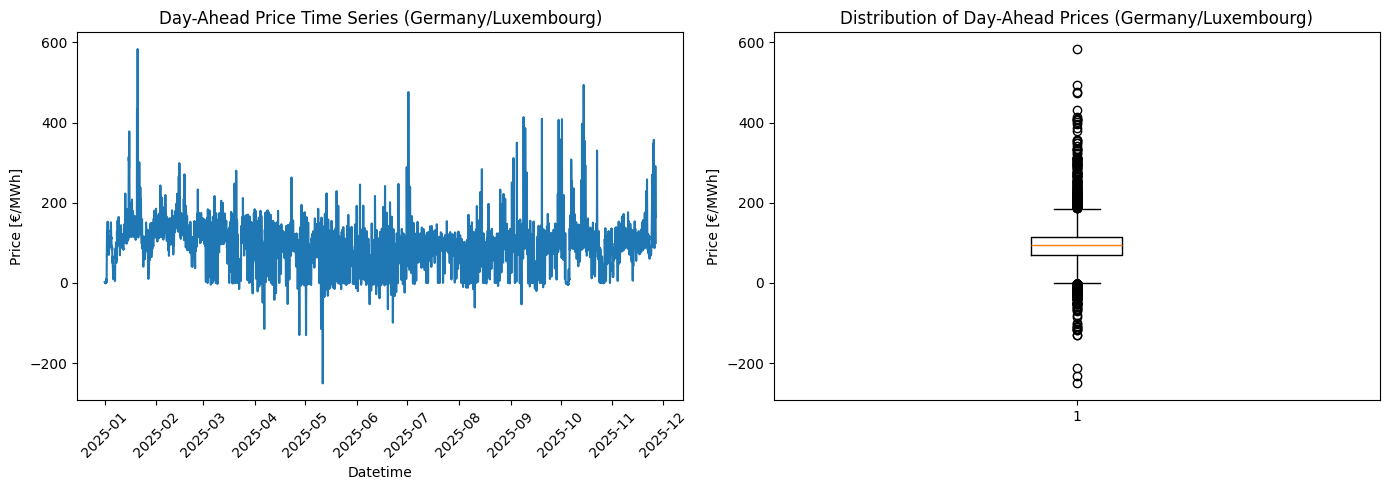

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series plot
axes[0].plot(df_combined["datetime"], df_combined["de_price"])
axes[0].set_title("Day-Ahead Price Time Series (Germany/Luxembourg)")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Price [€/MWh]")
for tl in axes[0].get_xticklabels():
  tl.set_rotation(45)

# Boxplot
axes[1].boxplot(df_combined["de_price"].dropna())
axes[1].set_title("Distribution of Day-Ahead Prices (Germany/Luxembourg)")
axes[1].set_ylabel("Price [€/MWh]")

plt.tight_layout()


In [10]:
day_ahead_hourly = pd.DataFrame(df_combined.resample("h", on="datetime")["de_price"].mean()).reset_index()
day_ahead_hourly.head(3)

,datetime,de_price
0,2025-01-01 00:00:00,2.16
1,2025-01-01 01:00:00,1.60
2,2025-01-01 02:00:00,0.00


In [49]:
ANNUAL_USAGE = 2_00_000
SCALE_FACTOR = ANNUAL_USAGE /1_000_000
FLAT_RATE_C_PER_KWH = 30
BATTERY_INEFFICIENCY_FACTOR = 0.9
ELECTRICITY_SHIFT_PROPORTION = 0.5

# additional costs
NETWORK_USAGE = 8.71
TAX_RATE = 0.19
ELECTRICITY_TAX = 2.05
ADDITIONAL_COST = 1.88
KONZESSION = 1.66
CHP_SURCHARGE = 0.45
COMBINED_ADDITIONAL_COSTS = NETWORK_USAGE + ELECTRICITY_TAX + ADDITIONAL_COST + KONZESSION + CHP_SURCHARGE 

df_usage_and_price = df_hourly.merge(
    day_ahead_hourly,
    on="datetime",
    how="left"
).rename(columns={"de_price": "c_per_kwh_variable", "value": "raw_kwh_usage"})

df_usage_and_price["c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"] / 10 # Convert €/MWh to c€/kWh

# Fill missing prices with average price
df_usage_and_price.loc[df_usage_and_price.c_per_kwh_variable.isna(), "c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"].mean()
df_usage_and_price["scaled_kwh_usage"] = df_usage_and_price["raw_kwh_usage"] * SCALE_FACTOR
df_usage_and_price["c_fixed_costs_kwh"] = COMBINED_ADDITIONAL_COSTS

df_usage_and_price["c_variable_and_fixed_per_kwh"] = df_usage_and_price["c_per_kwh_variable"] + df_usage_and_price["c_fixed_costs_kwh"]

df_usage_and_price["c_total_variable_cost"] = (
    (df_usage_and_price["scaled_kwh_usage"] * (df_usage_and_price["c_variable_and_fixed_per_kwh"])) * (1 + TAX_RATE)
)

df_usage_and_price["c_per_kwh_flat_rate_cost"] = FLAT_RATE_C_PER_KWH
df_usage_and_price["c_total_flat_cost"] = (df_usage_and_price["c_per_kwh_flat_rate_cost"] * df_usage_and_price["scaled_kwh_usage"]) * (1+TAX_RATE)


df_usage_and_price.head(3)

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_variable_and_fixed_per_kwh,c_total_variable_cost,c_per_kwh_flat_rate_cost,c_total_flat_cost
0,2025-01-01 00:00:00,14.4835,0.216,2.8967,14.75,14.966,51.588895,30,103.41219
1,2025-01-01 01:00:00,14.15175,0.160,2.83035,14.75,14.910,50.218617,30,101.043495
2,2025-01-01 02:00:00,13.97275,0.000,2.79455,14.75,14.750,49.051339,30,99.765435


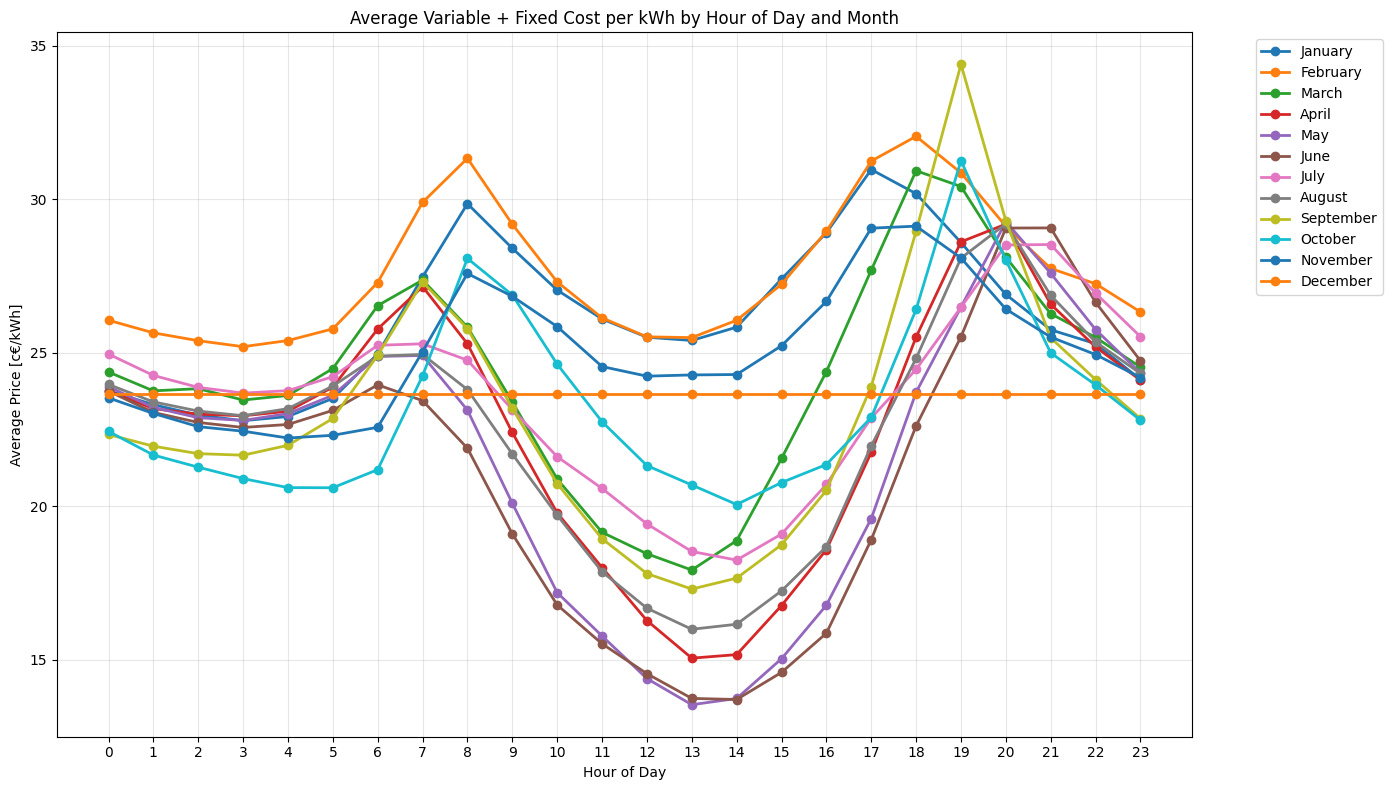

In [50]:
# Create a pivot table with hour of day as rows and month as columns
df_usage_and_price['month'] = df_usage_and_price['datetime'].dt.month
df_usage_and_price['month_name'] = df_usage_and_price['datetime'].dt.strftime('%B')
df_usage_and_price['hour_of_day'] = df_usage_and_price['datetime'].dt.hour

# Calculate average price by hour and month
hourly_monthly_avg = df_usage_and_price.groupby(['hour_of_day', 'month_name'])['c_variable_and_fixed_per_kwh'].mean().reset_index()

# Get unique months in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
months_in_data = [m for m in month_order if m in hourly_monthly_avg['month_name'].unique()]

# Create the plot
plt.figure(figsize=(14, 8))

for month in months_in_data:
    month_data = hourly_monthly_avg[hourly_monthly_avg['month_name'] == month]
    plt.plot(month_data['hour_of_day'], month_data['c_variable_and_fixed_per_kwh'], 
             marker='o', label=month, linewidth=2)

plt.xlabel('Hour of Day')
plt.ylabel('Average Price [c€/kWh]')
plt.title('Average Variable + Fixed Cost per kWh by Hour of Day and Month')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

np.float64(11.0)

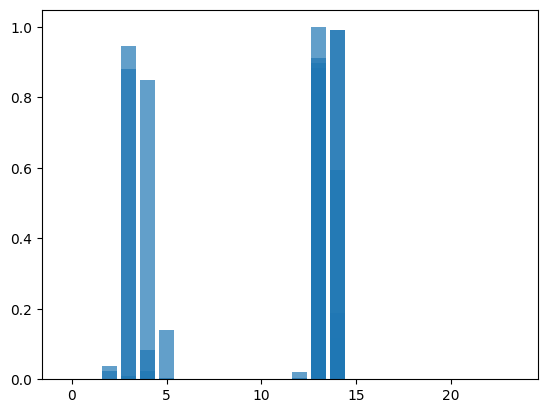

In [51]:
hourly_monthly_avg = df_usage_and_price.groupby(['hour_of_day', 'month_name'])['c_variable_and_fixed_per_kwh'].mean().reset_index()

g = hourly_monthly_avg.groupby("month_name")

# 1) Per-month weights (sum to 1 within each month)
hourly_monthly_avg["weighted_mean"] = g["c_variable_and_fixed_per_kwh"].transform(
    lambda x: x / x.sum()
)

# 2) Per-month inverse weights
hourly_monthly_avg["inverse_weighted_mean"] = g["weighted_mean"].transform(
    lambda x: x.max() - x
)

# 3) (Optional) Normalize inverse weights per month as well
hourly_monthly_avg["inverse_weighted_mean"] = g["inverse_weighted_mean"].transform(
    lambda x: x / x.sum()
)

T = 0.0005

hourly_monthly_avg["temperature_weighted"] = g["inverse_weighted_mean"].transform(
        lambda x: np.exp(x / T) / np.exp(x / T).sum()
)


# hourly_monthly_avg = temperature_weighting(hourly_monthly_avg, T=0.5)

plt.bar(hourly_monthly_avg['hour_of_day'], hourly_monthly_avg['temperature_weighted'], capsize=5, alpha=0.7)

hourly_monthly_avg["temperature_weighted"].sum()

In [52]:
hourly_monthly_avg.groupby(["month_name"], as_index=False).agg(
    {"temperature_weighted": "sum"}
)

,month_name,temperature_weighted
0,April,1.0
1,August,1.0
2,December,0.0
3,February,1.0
4,January,1.0
5,July,1.0
6,June,1.0
7,March,1.0
8,May,1.0
9,November,1.0


In [55]:
def shift_to_time(df, daily_df: pd.DataFrame, p: float = 0.5, on_cols=["day_of_year", "month_name"]) -> pd.DataFrame:
    """This function shifts electricity to be used primarily during hours when it is cheaper

    Args:
        df (pd.DataFrame) - the dateframe
        hour_range (list) - hours to shift the electricity usage to
        p (float) - proportion of electricity to shift
    
    Returns: 
        pd.DataFrame

    """

    df = df.copy()
    daily_df = daily_df.copy()

    df = df.merge(
        daily_df[["hour_of_day", "month_name", "temperature_weighted"]],
        left_on=[df["datetime"].dt.hour, df['datetime'].dt.month_name()],
        right_on=["hour_of_day", "month_name"],
        how="left"
    )

    df["day_of_year"] = df["datetime"].dt.dayofyear
    
    usage_by_day = df.groupby(["month_name", "day_of_year"], as_index=False)["scaled_kwh_usage"].sum()
    usage_by_day.rename(columns={"scaled_kwh_usage": "daily_total_usage_kwh"}, inplace=True)
    
    df = df.merge(
        usage_by_day,
        on=on_cols,
        how="left"
    )

    df["prop_shifted_usage"] = (df["temperature_weighted"] * df["daily_total_usage_kwh"]) 

    df["c_total_variable_shifted_cost"] = df["prop_shifted_usage"] * 1/BATTERY_INEFFICIENCY_FACTOR * (df["c_per_kwh_variable"] + df["c_fixed_costs_kwh"]) * (1 + TAX_RATE)

    df.drop(columns=["hour_of_day", "day_of_year", "hour_of_day_x", "hour_of_day_y", "temperature_weighted", "daily_total_usage_kwh"], inplace=True)
    return df

In [56]:
# df_temp = df_usage_and_price[(df_usage_and_price["datetime"] >= "2025-02-01") & (df_usage_and_price["datetime"] <= "2025-02-14")]
df_temp = df_usage_and_price[(df_usage_and_price["datetime"] <= "2025-11-30")]
# df_temp = df_usage_and_price.copy()
df_snippet = shift_to_time(df_temp, hourly_monthly_avg)
df_snippet


print(f'Shifted usage cost: €{df_snippet["c_total_variable_shifted_cost"].sum():,.2f}')
print(f'Original usage cost: €{df_snippet["c_total_variable_cost"].sum():,.2f}')

print(f'Shifted usage amount: {df_snippet["prop_shifted_usage"].sum():,.2f} kWh')
print(f'Original usage amount: {df_snippet["scaled_kwh_usage"].sum():,.2f} kWh')

Shifted usage cost: €1,135,243.52
Original usage cost: €1,282,444.93
Shifted usage amount: 45,474.33 kWh
Original usage amount: 45,477.11 kWh


In [18]:
df_temp = df_temp.merge(
    hourly_monthly_avg[["hour_of_day", "month_name", "temp_weighted"]],
    left_on=["hour_of_day", df_temp['datetime'].dt.month_name()],
    right_on=["hour_of_day", "month_name"],
    how="left"
)

In [257]:
df_temp

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_variable_and_fixed_per_kwh,c_total_variable_cost,c_per_kwh_flat_rate_cost,c_total_flat_cost,hour_of_day,month,month_name
0,2025-01-01 00:00:00,14.4835,0.216000,2.8967,14.75,14.966000,51.588895,30,103.41219,0,1,January
1,2025-01-01 01:00:00,14.15175,0.160000,2.83035,14.75,14.910000,50.218617,30,101.043495,1,1,January
2,2025-01-01 02:00:00,13.97275,0.000000,2.79455,14.75,14.750000,49.051339,30,99.765435,2,1,January
3,2025-01-01 03:00:00,13.861,-0.001000,2.7722,14.75,14.749000,48.655742,30,98.96754,3,1,January
4,2025-01-01 04:00:00,13.95375,-0.001000,2.79075,14.75,14.749000,48.981318,30,99.629775,4,1,January
...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2025-12-31 19:00:00,27.46925,8.913939,5.49385,14.75,23.663939,154.707299,30,196.130445,19,12,December
8756,2025-12-31 20:00:00,23.03,8.913939,4.606,14.75,23.663939,129.705365,30,164.4342,20,12,December
8757,2025-12-31 21:00:00,20.19275,8.913939,4.03855,14.75,23.663939,113.725923,30,144.176235,21,12,December
8758,2025-12-31 22:00:00,17.676,8.913939,3.5352,14.75,23.663939,99.551543,30,126.20664,22,12,December


In [219]:
df_snippet["prop_shifted_usage"].sum(), df_snippet["scaled_kwh_usage"].sum()

(50146.543149999685, 50146.5431500005)

In [80]:
df_temp = df_usage_and_price[(df_usage_and_price["datetime"] >= "2025-02-01") & (df_usage_and_price["datetime"] <= "2025-02-14")]
# df_snippet = scale_usage_for_shifted_electricity(df_temp, ELECTRICITY_SHIFT_PROPORTION)
df_snippet = shift_fraction(df_temp, ELECTRICITY_SHIFT_PROPORTION, shift_steps=14)


df_snippet["c_total_variable_shifted_cost"] = (
    (df_snippet["combined_shifted_scaled_usage_kwh"] * (df_snippet["c_per_kwh_variable"] + df_snippet["c_fixed_costs_kwh"])) * (1 + TAX_RATE)
)

original: 1956.3646999999978
combined: 1946.230555769232


/var/folders/mz/1tq8q4z116lfkx_8zp09v6wh0000gn/T/ipykernel_6854/3412376895.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["shifted_usage_scaled"] = p * shifted.fillna(shifted.mean())


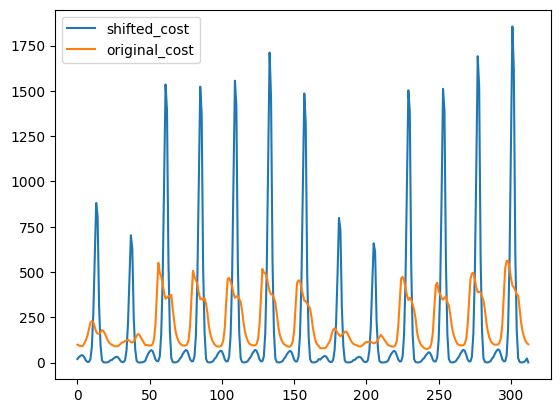

In [201]:
plt.plot(df_snippet["c_total_variable_shifted_cost"], label="shifted_cost")
plt.plot(df_snippet["c_total_variable_cost"], label="original_cost")
# plt.plot(df_snippet["scaled_kwh_usage"], label="scaled_kwh_usage")
# plt.plot(df_snippet["prop_shifted_usage"], label="shifted_usage")
# plt.plot(df_snippet["combined_shifted_scaled_usage_kwh"], label="combined_shifted_scaled_usage_kwh", c="green")
plt.legend()

In [199]:
df_snippet["scaled_kwh_usage"].sum(), df_snippet["prop_shifted_usage"].sum()

(1956.3646999999978, 1953.4261868535923)

In [84]:
df_snippet["c_total_variable_shifted_cost"].sum(), df_snippet["c_total_variable_cost"].sum()

(66123.49463952504, 67737.42682027996)

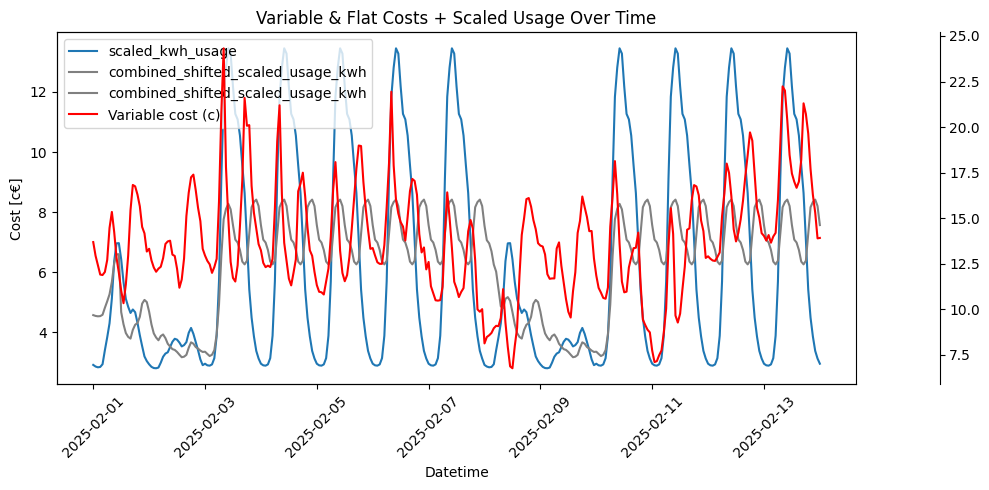

In [76]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Primary axis (left) ---
# ax1.plot(df_snippet["datetime"], df_snippet["c_per_kwh_variable"], label="Variable cost (c)")
# ax1.plot(df_snippet["datetime"], df_snippet["c_total_flat_cost"], label="Total Flat Cost")
ax1.plot(df_snippet["datetime"], df_snippet["scaled_kwh_usage"], label="scaled_kwh_usage")
ax1.plot(df_snippet["datetime"], df_snippet["combined_shifted_scaled_usage_kwh"], color="grey", label="combined_shifted_scaled_usage_kwh")
# ax1.plot(df_snippet["datetime"], df_snippet["c_total_variable_shifted_cost"], label="Cost with Shifted Usage")

ax1.set_xlabel("Datetime")
ax1.set_ylabel("Cost [c€]")
ax1.tick_params(axis='x', rotation=45)

# --- Secondary axis (right) ---
# ax2 = ax1.twinx()
# ax2.plot(df_snippet["datetime"], df_snippet["combined_shifted_scaled_usage_kwh"], color="grey", label="combined_shifted_scaled_usage_kwh")
# # ax2.plot(df_snippet["datetime"], df_snippet["shifted_usage"], color="green", linestyle="--", label="Shifted kWh Usage")
# ax2.set_ylabel("Scaled kWh Usage")

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset
ax3.plot(df_snippet["datetime"], df_snippet["c_per_kwh_variable"], label="Variable cost (c)", c="red")

# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc="upper left")

plt.title("Variable & Flat Costs + Scaled Usage Over Time")
plt.tight_layout()
plt.show()

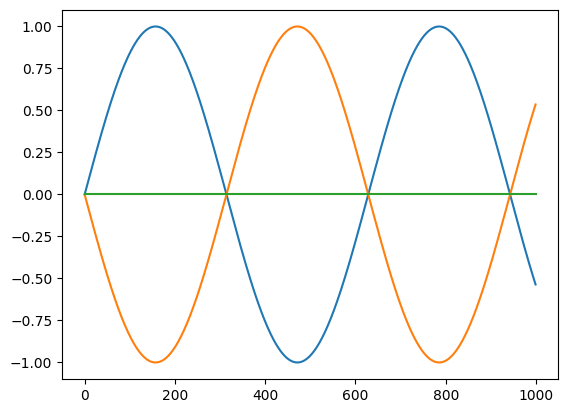

In [20]:
import numpy as np
x1 = np.sin(np.arange(0, 10, 0.01))
x2 = np.sin(np.arange(np.pi, 10+np.pi, 0.01))

x3 = 0.5 * x1 + 0.5 * x2

plt.plot(x1)
plt.plot(x2)
plt.plot(x3)
